# 4. Controle automático: experimento de sensibilidade para pesquisa

**Pergunta:** um preditor de consumo responde a alterações hipotéticas do comando de acelerador e esses cenários se parecem com dados de treino?
**Tipo:** regressão supervisionada + exploração observacional de cenários. Este notebook **não controla o veículo**, não prova economia e não estima efeito causal de uma intervenção.

Primeiro avaliamos previsão da média de consumo nos próximos 10 s em ensaios não vistos. Depois alteramos apenas `Acc(t)` em ±10 pontos percentuais, mantendo as amostras anteriores e as outras leituras no instante t. Os resumos de acelerador que incluem t são recalculados de forma consistente. Isso representa um possível início de mudança de comando, não uma trajetória fisicamente simulada. `Diem` envolve tempo de abertura e pressão de injeção. O arquivo contém uma única coluna escalar, ausente em dois ensaios, sem correspondência documentada com essas duas grandezas. Ela não é usada como atuador neste experimento.

Uma extensão real exigiria modelo de dinâmica, demanda de torque, restrições de emissões, segurança e dados experimentais/simulador. Aqui examinamos a peça preditiva e seus limites.

**Limite dos Pi:** `Pi_6` também contém tempo decorrido (`Temp²` no denominador). A exclusão de `Pi_4` não elimina esse efeito. O modelo mantém `Pi_6` para explorar os dados disponíveis; testar sua remoção é uma análise futura, não realizada aqui.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
get_ipython().run_line_magic("matplotlib", "inline")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Motor/Dados/Data_set.CSV").is_file())
sys.path.insert(0, str(ROOT / "Motor/notebooks"))
from consumo_utils import load_data, forecast_frame, regressor, accelerator_scenario
OUT = ROOT / "Motor/resultados_consumo/04_controle_automatico"
OUT.mkdir(parents=True, exist_ok=True)
dados = load_data(ROOT)
manifest = {
    "python": platform.python_version(), "pandas": pd.__version__,
    "numpy": np.__version__, "scikit_learn": sklearn.__version__,
    "seed": 42, "unidade": "U = unidade numérica de Taccm; unidade física não confirmada",
    "sha256": {name: hashlib.sha256((ROOT / "Motor/Dados" / name).read_bytes()).hexdigest()
               for name in ["Data_set.CSV", "Data_set_param.CSV", "Dataset_Modelagem_Pi.csv"]},
}
(OUT / "ambiente.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Amostras por ensaio:", dados.groupby("Experimento").size().to_dict())
print("Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.")

Amostras por ensaio: {'D1T1A': 1984, 'D1T1B': 1776, 'D1T2': 3876, 'D2T1': 1703}
Unidades: taxa em U; integral em U·s. Sem conversão automática para litros.


In [2]:
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
frame,features=forecast_frame(dados,horizon=10,history=10,stride=10)
display(dados.groupby("Experimento").Diem.count().rename("Diem disponível"))

Experimento
D1T1A       0
D1T1B       0
D1T2     3876
D2T1     1703
Name: Diem disponível, dtype: int64

## Avaliação e filtro de proximidade ao treino

A distância é calculada no espaço de atributos imputados e padronizados com o treino. O limite é o percentil 95 da distância de cada ponto de treino ao seu vizinho mais próximo, excluindo ele próprio. Um cenário só recebe a marca de proximidade se tanto o estado observado quanto o modificado ficarem dentro desse limite. Isso é uma heurística de suporte estatístico; não garante viabilidade física ou causalidade.

Escolhemos instantes com `Acc` entre 10% e 90% e velocidade positiva para que ±10 pontos percentuais fique na faixa observada de comando. Não usamos o consumo futuro real para escolher as alternativas.

In [3]:
metrics=[]; scenario_rows=[]
for experiment in sorted(frame.Experimento.unique()):
    train=frame[frame.Experimento!=experiment]
    test=frame[frame.Experimento==experiment]
    model=regressor()
    model.fit(train[features],train.fuel_future_mean)
    predicted=np.maximum(0,model.predict(test[features]))
    metrics.append(dict(ensaio=experiment,n=len(test),
        mae_modelo=mean_absolute_error(test.fuel_future_mean,predicted),
        mae_persistencia=mean_absolute_error(test.fuel_future_mean,test.cur_Taccm)))
    scaling=make_pipeline(SimpleImputer(strategy="median",add_indicator=True),StandardScaler())
    Xtrain=scaling.fit_transform(train[features])
    neighbors=NearestNeighbors(n_neighbors=2).fit(Xtrain)
    threshold=np.quantile(neighbors.kneighbors(Xtrain)[0][:,1],.95)
    candidates=test[test.cur_Acc.between(10,90) & (test.cur_Velo>0)].copy()
    for action in [-10,10]:
        if candidates.empty: continue
        modified=accelerator_scenario(candidates[features], delta=action, history=10)
        distance=neighbors.kneighbors(scaling.transform(modified),n_neighbors=1)[0][:,0]
        base_distance=neighbors.kneighbors(scaling.transform(candidates[features]),n_neighbors=1)[0][:,0]
        original=np.maximum(0,model.predict(candidates[features]))
        changed=np.maximum(0,model.predict(modified))
        records=candidates[["Experimento","Temp","cur_Acc","cur_Velo","cur_Tau"]].copy()
        records["delta_Acc_pp"]=action
        records["previsao_original"]=original
        records["previsao_cenario"]=changed
        records["delta_previsao_U"]=changed-original
        records["distancia"]=distance;records["limite_distancia"]=threshold
        records["proximo_treino"]=(distance<=threshold)&(base_distance<=threshold)
        scenario_rows.append(records)
metrics=pd.DataFrame(metrics);scenarios=pd.concat(scenario_rows,ignore_index=True)
summary=scenarios.groupby(["Experimento","delta_Acc_pp"]).agg(
    n=("Temp","size"),fracao_proxima=("proximo_treino","mean"),
    delta_mediano=("delta_previsao_U","median"),delta_medio=("delta_previsao_U","mean"))
supported=scenarios[scenarios.proximo_treino].groupby(["Experimento","delta_Acc_pp"]).agg(
    n_proximos=("Temp","size"),delta_medio_proximos=("delta_previsao_U","mean"))
summary=summary.join(supported)
metrics.to_csv(OUT/"metricas.csv",index=False)
scenarios.to_csv(OUT/"cenarios.csv",index=False)
summary.to_csv(OUT/"resumo_cenarios.csv")
display(metrics.round(3));display(summary.round(3))

,ensaio,n,mae_modelo,mae_persistencia
0,D1T1A,197,5.294,5.658
1,D1T1B,176,5.359,5.448
2,D1T2,386,5.589,4.285
3,D2T1,169,5.475,4.357


n  fracao_proxima  delta_mediano  delta_medio  \
Experimento delta_Acc_pp                                                    
D1T1A       -10            93           0.839         -0.876       -1.534   
             10            93           0.839          1.231        2.758   
D1T1B       -10            57           0.860         -0.898       -2.696   
             10            57           0.860          1.135        2.042   
D1T2        -10           161           0.975         -0.085       -1.165   
             10           161           0.969          1.109        3.086   
D2T1        -10            80           0.000         -0.682       -1.779   
             10            80           0.000          3.503        4.620   

                          n_proximos  delta_medio_proximos  
Experimento delta_Acc_pp                                    
D1T1A       -10                 78.0                -1.252  
             10                 78.0                 2.846  
D1T1B       -10                 49.0                -2.813  
             10                 49.0                 2.231  
D1T2        -10                157.0                -1.213  
             10                156.0                 3.131  
D2T1        -10                  NaN                   NaN  
             10                  NaN                   NaN

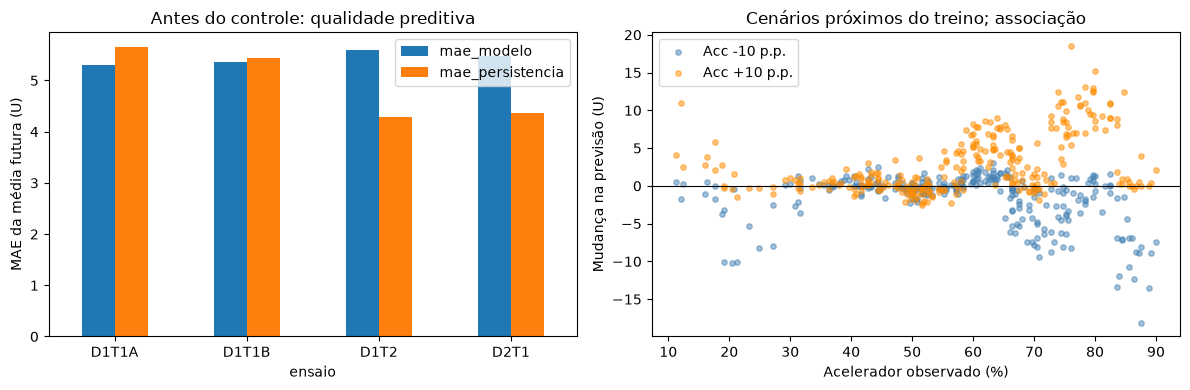

Foram avaliados **782 cenários**, dos quais **72.5%** ficaram dentro do critério de proximidade. Diferenças na previsão não são economia medida. Não escolher automaticamente o menor valor: a demanda de torque e a resposta dinâmica não foram modeladas.

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
metrics.set_index("ensaio")[["mae_modelo","mae_persistencia"]].plot.bar(ax=axes[0])
axes[0].set(ylabel="MAE da média futura (U)",title="Antes do controle: qualidade preditiva")
axes[0].tick_params(axis="x",rotation=0)
for action,color in [(-10,"steelblue"),(10,"darkorange")]:
    subset=scenarios[(scenarios.delta_Acc_pp==action)&scenarios.proximo_treino]
    axes[1].scatter(subset.cur_Acc,subset.delta_previsao_U,s=15,alpha=.5,c=color,label=f"Acc {action:+d} p.p.")
axes[1].axhline(0,color="black",linewidth=.8)
axes[1].set(xlabel="Acelerador observado (%)",ylabel="Mudança na previsão (U)",title="Cenários próximos do treino; associação")
axes[1].legend()
fig.tight_layout();fig.savefig(OUT/"sensibilidade_controle.png",dpi=150);plt.show()
rate=scenarios.proximo_treino.mean()
display(Markdown(f"Foram avaliados **{len(scenarios)} cenários**, dos quais **{rate:.1%}** ficaram dentro "
    "do critério de proximidade. Diferenças na previsão não são economia medida. "
    "Não escolher automaticamente o menor valor: a demanda de torque e a resposta dinâmica não foram modeladas."))

## O que falta para controlar a injeção

O modelo foi treinado com ações observadas do motorista, não intervenções aleatórias. Reduzir acelerador pode diminuir a demanda atendida; o modelo não verifica desempenho equivalente. O critério de proximidade não remove esse confundimento. Para regular injeção seria preciso observar o comando de injeção, identificar a dinâmica entre esse comando, torque, consumo e demais saídas e validar um controlador em simulação e experimentos. Portanto, o resultado deste notebook é uma avaliação de sensibilidade do preditor, não um controlador pronto.

### Esclarecimento sobre `Diem` — 27/09/2026

**`Diem` representa tempo de abertura da injeção + pressão de injeção**. O “+” indica a participação das duas grandezas na descrição da injeção; ele não define uma soma numérica entre tempo e pressão, que têm dimensões diferentes.

Nos arquivos disponíveis há uma única coluna `Diem` por ensaio, identificada como m³/s. A planilha também menciona uma grandeza de origem em mm³/ciclo. Não há colunas separadas de duração de abertura e pressão nos cabeçalhos dos dados. Portanto, a definição conceitual está registrada, mas ainda falta confirmar **como duração e pressão foram transformadas no valor escalar de `Diem`**, suas unidades e se o registro é medição, comando ou valor calculado.

- **Previsão supervisionada:** uma próxima comparação pode acrescentar `Diem(t)` e seu histórico para prever consumo futuro, usando somente D1T2 e D2T1, onde a variável existe. Comparar modelos com e sem `Diem` nas mesmas janelas, treinando em um ensaio e testando no outro, sem seleção de parâmetros no teste. Não usar `Diem` futuro nem preencher ensaios inteiros ausentes com zero. Com apenas dois ensaios, a conclusão será exploratória. Essa comparação ainda não foi executada.
- **Análise não supervisionada:** nesses mesmos dois ensaios, explorar agrupamentos de `Diem`, `Tau`, `n` e consumo, com padronização e comparação da composição por ensaio. Os grupos indicariam regimes observados de injeção/operação; não identificariam separadamente o efeito da pressão e da abertura.
- **Controle:** para testar duração de abertura e pressão como duas ações, precisamos das duas séries separadas, unidades, limites, sincronização e identificação de comandos versus medições. Uma única coluna composta não permite recuperar de forma única esses dois valores. A simulação executada continua atuando sobre `Acc`; a definição recebida não permite transformá-la em controle de injeção.
- **`Pi_5`:** a expressão `Diem / (Temp² × Velo³)` só é adimensional sob a dimensão de vazão (L³/T) declarada na tabela atual. A nova descrição conceitual não confirma essa dimensão. Se `Diem` tiver outra dimensão ou for desdobrada em duração e pressão, será necessário corrigir os metadados e recalcular os grupos Pi. Os Pi existentes mantêm a hipótese documental original.

A unidade/calibração de `Taccm` continua pendente. Os resultados já executados não usam `Diem` nem `Pi_5` como entrada e não mudam com esse esclarecimento.


## Melhorias aplicadas: dinâmica, restrições e simulação comparável

Além da sensibilidade acima, ajustamos uma dinâmica observacional de **1 segundo**: estado atual (`Velo`, `n`, `Tau`, `Taccm`), acelerador, freio, marcha e temperaturas → próximo estado. Um modelo por saída é treinado nos três ensaios e testado no quarto. Comparamos MAE de cada saída com persistência.

Depois simulamos janelas completas de 10 s, sem reinserir o estado real a cada passo: ambos os métodos começam do mesmo estado, mas seus estados seguintes vêm do modelo. O **replay nominal** segue o acelerador registrado. O **controlador simulado** compara acelerador nominal −5, nominal e nominal +5 pontos percentuais, limitados a 0–100%.

A demanda de referência é a trajetória registrada de velocidade e torque, declarada previamente para o estudo. Freio, marcha e temperaturas são agendas exógenas também reproduzidas e iguais nos dois métodos. Trata-se de um benchmark com agenda conhecida, não um controlador que prevê o trânsito ou conhece sinais futuros em uso real.

Um candidato só é elegível se o próximo estado previsto ficar a até **2 unidades de Velo** e **160 N·m de Tau** da referência e passar pelo filtro de proximidade do estado nominal e candidato ao treino. São tolerâncias de estudo, sem validação de engenharia. Entre candidatos elegíveis, escolhemos menor consumo previsto; empate mantém comando nominal. Se nenhum for elegível, usamos replay e contamos um fallback. Esse fallback não garante que as restrições sejam satisfeitas; as violações também são medidas.

Não há modelo de emissões, identificação causal da injeção nem atuação no ônibus. A diferença de consumo entre políticas é **interna ao simulador aprendido**, não economia medida.

In [5]:
NEW=OUT/"melhorias"
NEW.mkdir(exist_ok=True)
new_manifest=dict(manifest)
new_manifest["codigo_sha256"]={name:hashlib.sha256((ROOT/"Motor/notebooks"/name).read_bytes()).hexdigest()
                              for name in ["consumo_utils.py","consumo_melhorias.py"]}
(NEW/"ambiente.json").write_text(json.dumps(new_manifest,indent=2,ensure_ascii=False))

696

In [6]:
from openpyxl import load_workbook
book_path=ROOT/"Motor/Dados/Data_set.xlsx"
book=load_workbook(book_path,read_only=True,data_only=False)
metadata=[]
for sheet in ["Resumo dos Dados","Resumo útio"]:
    for row in book[sheet].values:
        if any(v is not None and ("Inje" in str(v) or "Consumo" in str(v)) for v in row):
            metadata.append({"aba":sheet,"valores":list(row)})
book.close()
audit={"metadados_planilha":metadata,
       "Diem_amostras":dados.groupby("Experimento").Diem.count().to_dict(),
       "Taccm_min":float(dados.Taccm.min()),"Taccm_max":float(dados.Taccm.max()),
       "Diem_esclarecimento":{
           "fonte":"Definição conceitual adotada na análise; correspondência com a coluna ainda não validada",
           "definicao_informada":"Tempo de abertura da injeção + pressão de injeção",
           "interpretacao":"Participação das duas grandezas; não uma soma numérica de tempo e pressão.",
           "representacao_arquivo":"Uma coluna escalar Diem por ensaio, rotulada m³/s; sem colunas separadas de abertura e pressão nos cabeçalhos dos dados.",
           "pendencias":["Mapeamento de abertura e pressão para Diem e suas unidades", "Identificação de medição, comando ou valor calculado", "Séries separadas e limites dos dois comandos para controle"],
           "Pi_5":"Adimensional somente sob a hipótese documental Diem com dimensão L³/T.",
           "efeito_modelos":"Modelos executados não usam Diem nem Pi_5; simulação altera Acc."},
       "conclusao":"Diem envolve tempo de abertura e pressão de injeção. A planilha registra um escalar rotulado m³/s e origem em mm³/ciclo; falta confirmar sua relação numérica com essas duas grandezas e se é medição ou comando. Não há atuação independente sobre abertura e pressão. Unidade/calibração de Taccm permanece pendente."}
(NEW/"auditoria_sensores.json").write_text(json.dumps(audit,indent=2,ensure_ascii=False))
new_manifest["sha256"]["Data_set.xlsx"]=hashlib.sha256(book_path.read_bytes()).hexdigest()
(NEW/"ambiente.json").write_text(json.dumps(new_manifest,indent=2,ensure_ascii=False))
display(Markdown(audit["conclusao"]))
from consumo_melhorias import run_control
controlled=run_control(dados,horizon=10,vtol=2.,ttol=160.)
for name,table in controlled.items():table.to_csv(NEW/f"{name}.csv",index=False)
display(controlled["dinamica_1s"].round(3))
display(controlled["simulacao_resumo"].round(3))

Diem envolve tempo de abertura e pressão de injeção. A planilha registra um escalar rotulado m³/s e origem em mm³/ciclo; falta confirmar sua relação numérica com essas duas grandezas e se é medição ou comando. Não há atuação independente sobre abertura e pressão. Unidade/calibração de Taccm permanece pendente.

Dinâmica/simulação: teste D1T1A


Dinâmica/simulação: teste D1T1B


Dinâmica/simulação: teste D1T2


Dinâmica/simulação: teste D2T1


,ensaio,variavel,n,mae_modelo,mae_persistencia
0,D1T1A,Velo,1983,0.572,0.760
1,D1T1A,n,1983,0.647,0.749
2,D1T1A,Tau,1983,76.561,77.604
3,D1T1A,Taccm,1983,2.364,2.525
4,D1T1B,Velo,1775,0.575,0.725
5,D1T1B,n,1775,0.660,0.766
6,D1T1B,Tau,1775,75.362,74.655
7,D1T1B,Taccm,1775,2.189,2.482
8,D1T2,Velo,3875,0.633,0.757
9,D1T2,n,3875,0.618,0.679


,ensaio,metodo,janelas,passos,integral_simulada,integral_observada_referencia,mae_integral_replay,mae_velo,mae_tau,fracao_violacao_velo,fracao_violacao_tau,fracao_aceita,fracao_alterada,fracao_fallback
0,D1T1A,controlador_simulado,198,1980,20502.422,21036.45,NaN,2.547,116.775,0.440,0.234,0.368,0.121,0.632
1,D1T1A,replay,198,1980,21079.133,21036.45,17.655,2.556,118.230,0.451,0.254,0.000,0.000,NaN
2,D1T1B,controlador_simulado,177,1770,17750.883,18160.10,NaN,2.447,127.574,0.390,0.262,0.473,0.103,0.527
3,D1T1B,replay,177,1770,17963.395,18160.10,19.144,2.426,129.089,0.384,0.279,0.000,0.000,NaN
4,D1T2,controlador_simulado,387,3870,34232.596,37492.50,NaN,2.870,117.527,0.440,0.228,0.437,0.115,0.563
5,D1T2,replay,387,3870,34663.853,37492.50,20.805,2.884,119.357,0.453,0.250,0.000,0.000,NaN
6,D2T1,controlador_simulado,170,1700,16299.333,17789.00,NaN,7.281,145.755,0.797,0.360,0.000,0.000,1.000
7,D2T1,replay,170,1700,16299.333,17789.00,24.772,7.281,145.755,0.797,0.360,0.000,0.000,NaN


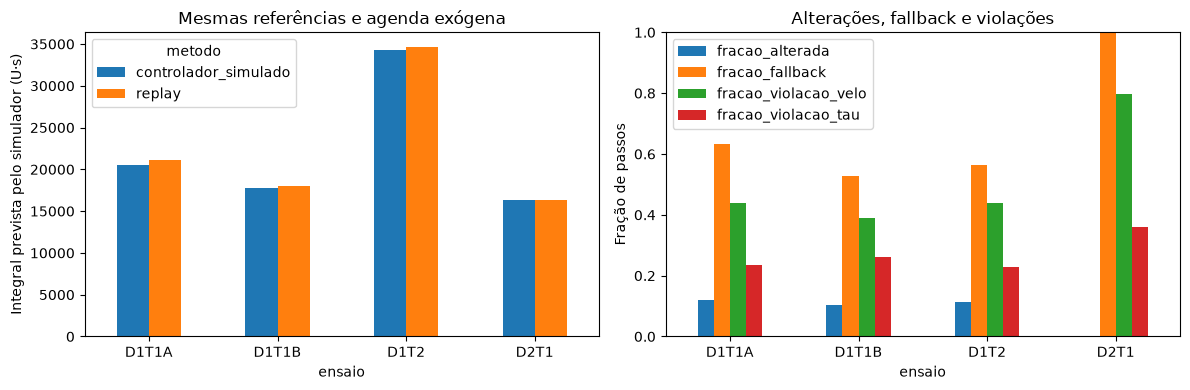

**Interpretação:** comparar integral simulada junto com atendimento da demanda, violações, fallback e erros do replay de 10 s. Uma previsão barata que reduz o serviço prestado não é uma melhoria válida. As respostas contrafactuais do modelo observacional ainda exigem validação em simulador físico ou experimentos.

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
summary=controlled["simulacao_resumo"]
summary.pivot(index="ensaio",columns="metodo",values="integral_simulada").plot.bar(ax=axes[0])
axes[0].set(ylabel="Integral prevista pelo simulador (U·s)",title="Mesmas referências e agenda exógena")
policy=summary[summary.metodo=="controlador_simulado"].set_index("ensaio")
policy[["fracao_alterada","fracao_fallback","fracao_violacao_velo","fracao_violacao_tau"]].plot.bar(ax=axes[1])
axes[1].set(ylabel="Fração de passos",title="Alterações, fallback e violações",ylim=(0,1))
for ax in axes:ax.tick_params(axis="x",rotation=0)
fig.tight_layout();fig.savefig(NEW/"controle_simulado.png",dpi=150);plt.show()
display(Markdown("**Interpretação:** comparar integral simulada junto com atendimento da demanda, violações, "
    "fallback e erros do replay de 10 s. Uma previsão barata que reduz o serviço prestado não é uma melhoria válida. "
    "As respostas contrafactuais do modelo observacional ainda exigem validação em simulador físico ou experimentos."))